In [6]:
# Load the file into colab
import pandas as pd

# Load CSV file
df = pd.read_csv("/content/drive/MyDrive/student_performance_large_dataset.csv")

# View first 5 rows
df.head()


,Student_ID,Department,Marks,Attendance_Percentage,Study_Hours_Per_Week,Internship_Completed,Placed
0,1,MECH,45,69,16,Yes,No
1,2,CIVIL,85,77,37,Yes,Yes
2,3,EEE,86,74,20,No,No
3,4,CIVIL,77,82,17,Yes,No
4,5,CIVIL,92,64,25,Yes,Yes


In [7]:
#Give different departments available
df['Department'].unique()

array(['MECH', 'CIVIL', 'EEE', 'ECE', 'CSE'], dtype=object)

In [8]:
# Show me basic information about the dataset
# What are the columns and data types?
# Are there missing values?
# Give summary statistics for numerical columns
df.info()
df.dtypes
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student_ID             50000 non-null  int64 
 1   Department             50000 non-null  object
 2   Marks                  50000 non-null  int64 
 3   Attendance_Percentage  50000 non-null  int64 
 4   Study_Hours_Per_Week   50000 non-null  int64 
 5   Internship_Completed   50000 non-null  object
 6   Placed                 50000 non-null  object
dtypes: int64(4), object(3)
memory usage: 2.7+ MB


,Student_ID,Marks,Attendance_Percentage,Study_Hours_Per_Week
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,66.915240,74.392240,21.987800
std,14433.901067,18.765288,14.433202,10.096939
min,1.000000,35.000000,50.000000,5.000000
25%,12500.750000,51.000000,62.000000,13.000000
50%,25000.500000,67.000000,74.000000,22.000000
75%,37500.250000,83.000000,87.000000,31.000000
max,50000.000000,99.000000,99.000000,39.000000


In [10]:
# Filter students who completed internship
internship_completed_df = df[df["Internship_Completed"] == "Yes"]

# View study hours of those students
internship_completed_df["Study_Hours_Per_Week"].head()


,Study_Hours_Per_Week
0,16
1,37
3,17
4,25
8,12


In [12]:
df.columns.tolist()

['Student_ID',
 'Department',
 'Marks',
 'Attendance_Percentage',
 'Study_Hours_Per_Week',
 'Internship_Completed',
 'Placed']

In [13]:
placed_after_internship = df[
    (df["Internship_Completed"] == "Yes") &
    (df["Placed"] == "Yes")
]

# Count such students
count = placed_after_internship.shape[0]

print("Number of students who completed internship and got placed:", count)


Number of students who completed internship and got placed: 12601


In [17]:
dept_placement = (
    df[df["Placed"] == "Yes"]
    .groupby("Department")
    .size()
    .sort_values(ascending=False)
)

print(dept_placement)

Department
CIVIL    5080
MECH     5039
ECE      5034
CSE      4989
EEE      4888
dtype: int64


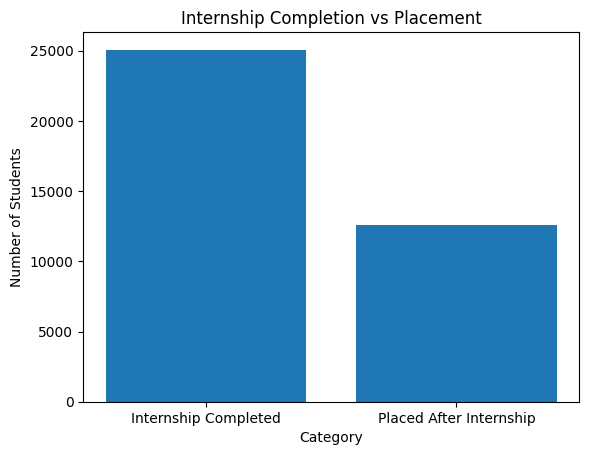

In [15]:
import matplotlib.pyplot as plt
internship_completed = df[df["Internship_Completed"] == "Yes"].shape[0]
placed_after_internship = df[
    (df["Internship_Completed"] == "Yes") &
    (df["Placed"] == "Yes")
].shape[0]

# Plot
plt.figure()
plt.bar(
    ["Internship Completed", "Placed After Internship"],
    [internship_completed, placed_after_internship]
)
plt.title("Internship Completion vs Placement")
plt.xlabel("Category")
plt.ylabel("Number of Students")
plt.show()


<Axes: xlabel='Department'>

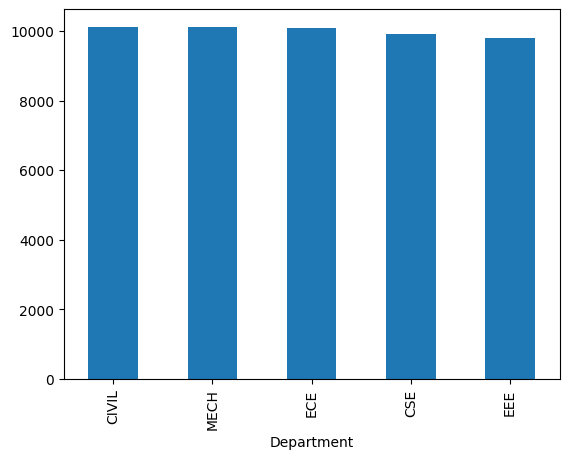

In [5]:
# Visualize department-wise student count
df["Department"].value_counts().plot(kind="bar")


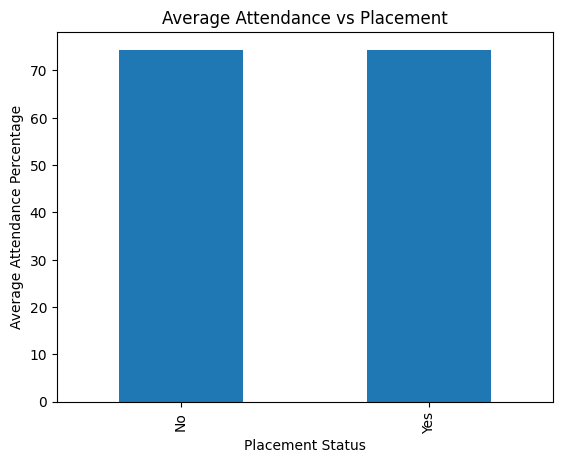

In [16]:
attendance_summary = df.groupby("Placed")["Attendance_Percentage"].mean()

# Plot
plt.figure()
attendance_summary.plot(kind="bar")
plt.title("Average Attendance vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Average Attendance Percentage")
plt.show()


Internship_Completed
No     66.860690
Yes    66.969485
Name: Marks, dtype: float64


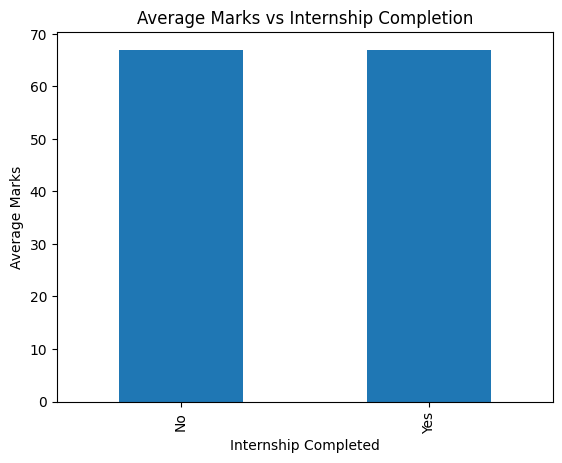

In [20]:
marks_summary = df.groupby("Internship_Completed")["Marks"].mean()

print(marks_summary)

# Plot
plt.figure()
marks_summary.plot(kind="bar")
plt.title("Average Marks vs Internship Completion")
plt.xlabel("Internship Completed")
plt.ylabel("Average Marks")
plt.show()

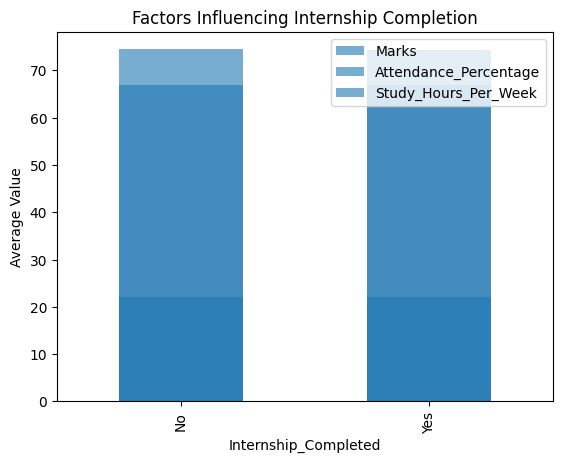

In [21]:
import matplotlib.pyplot as plt

factors = ["Marks", "Attendance_Percentage", "Study_Hours_Per_Week"]

plt.figure()
for factor in factors:
    df.groupby("Internship_Completed")[factor].mean().plot(
        kind="bar", alpha=0.6, label=factor
    )

plt.title("Factors Influencing Internship Completion")
plt.ylabel("Average Value")
plt.legend()
plt.show()
